# Proyek Deteksi Fraud
Implementasi *end-to-end* sistem deteksi penipuan (fraud) memanfaatkan MLflow dan Optuna.

## 1. Persiapan Lingkungan dan Import Library
Langkah pertama adalah menginstal seluruh pustaka yang dibutuhkan secara senyap (*quiet install*) di *runtime*. Selanjutnya, kita akan mengimpor *library* penting, menyambungkan penyimpanan ke Google Drive, dan memuat dataset untuk melihat struktur awalnya.

In [3]:
# Install libraries
!pip install -q mlflow optuna catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import drive

warnings.filterwarnings('ignore')

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)
path = '/content/drive/MyDrive/FTERM_ML/train_transaction.csv'

# Load dataset
df = pd.read_csv(path)
print(f'Shape dataset: {df.shape}')
display(df.head())

Mounted at /content/drive
Shape dataset: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Exploratory Data Analysis (EDA)
Pada tahap ini, kita akan menelusuri distribusi label target (`isFraud`) serta menggali pola dan korelasi antar fitur.

**Insight dari Distribusi Target:**
Dari visualisasi, terlihat jelas bahwa dataset kita mengalami ketidakseimbangan kelas (*imbalanced data*) yang ekstrem. Transaksi yang sah mendominasi sekitar ~96.5%, sementara kasus penipuan hanya berada di angka ~3.5%. Fakta ini sangat penting karena tanpa penanganan yang tepat, model *Machine Learning* bisa menjadi bias dan sepenuhnya mengabaikan kelas minoritas (fraud).

**Analisis Nilai Transaksi & Kode Produk:**
* **Distribusi Logaritmik Nilai Transaksi:** Kita menggunakan transformasi log (*log scale*) karena nominal transaksi bervariasi sangat drastis (*highly skewed*). Transformasi ini membantu kita memetakan pola distribusi nominal transaksi dengan lebih jelas.
* **Perbandingan Kode Produk vs Status Fraud:** Grafik ini memperlihatkan frekuensi penggunaan tiap kode produk. Melalui plot ini, kita bisa mengidentifikasi apakah terdapat kode produk tertentu (misalnya 'C' atau 'W') yang lebih rentan atau sering dieksploitasi untuk transaksi fraud.

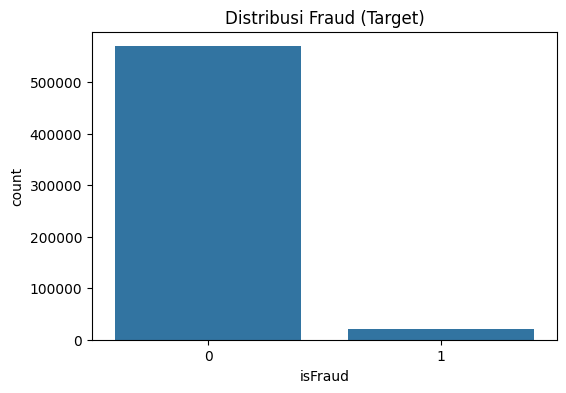

Persentase Fraud:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


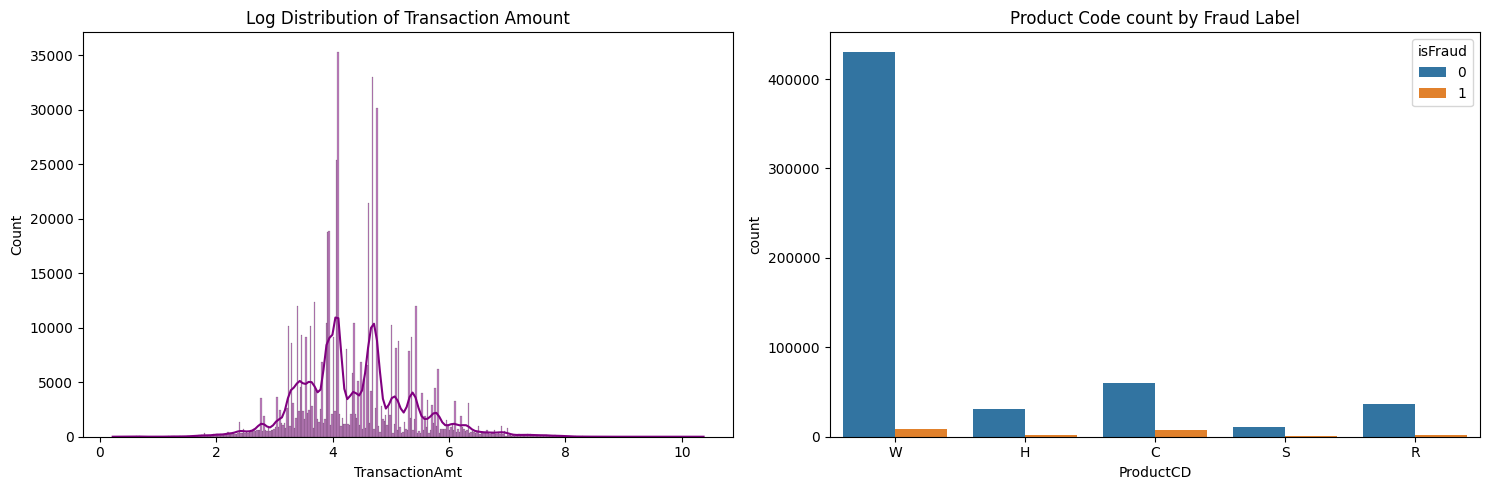

In [4]:
# Visualisasi Distribusi Target
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title('Distribusi Fraud (Target)')
plt.show()

print("Persentase Fraud:")
print(df['isFraud'].value_counts(normalize=True) * 100)

# Visualisasi Log TransactionAmt dan ProductCD
plt.figure(figsize=(15, 5))

# Grafik 1: Distribusi Log TransactionAmt
plt.subplot(1, 2, 1)
sns.histplot(np.log1p(df['TransactionAmt']), kde=True, color='purple')
plt.title('Log Distribution of Transaction Amount')

# Grafik 2: ProductCD Count vs isFraud
plt.subplot(1, 2, 2)
sns.countplot(x='ProductCD', hue='isFraud', data=df)
plt.title('Product Code count by Fraud Label')

plt.tight_layout()
plt.show()

## 3. Pra-pemrosesan Data (Data Preprocessing)
Sebelum masuk ke tahap permodelan, data mentah harus dibersihkan. Proses ini meliputi eliminasi fitur/kolom yang memiliki terlalu banyak nilai kosong (*missing values*)—di sini kita membuang kolom yang data kosongnya lebih dari 50%. Untuk sisa *missing values* di kolom lainnya, kita melakukan teknik imputasi sederhana: mengisi dengan nilai median untuk data numerik, dan nilai modus untuk data kategorik.

In [5]:
# Identifikasi dan drop kolom dengan > 50% missing values
null_cols = [col for col in df.columns if df[col].isnull().sum() / df.shape[0] > 0.5]
df.drop(columns=null_cols, inplace=True)

# Imputasi missing values sisa
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("Pembersihan data selesai. Dataset 'df' siap untuk diproses lebih lanjut.")

Pembersihan data selesai. Dataset 'df' siap untuk diproses lebih lanjut.


## 4. Pembagian Dataset (Train-Test Split)
Agar model dapat dievaluasi secara objektif, data akan dibagi menjadi dua himpunan: *Training Set* (untuk melatih model) dan *Test Set* (sebagai ujian pada data yang belum pernah dilihat model).

Kita menggunakan rasio pembagian 80:20. Tidak lupa, kita menerapkan *One-Hot Encoding* untuk mengubah data kategorikal menjadi format numerik. Penggunaan parameter `stratify` juga diaplikasikan untuk memastikan proporsi kelas fraud tetap seimbang antara set pelatihan dan pengujian.

In [6]:
from sklearn.model_selection import train_test_split

# Memisahkan Fitur dan Target
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# One-hot encoding untuk data kategorikal
X = pd.get_dummies(X, drop_first=True)

# Splitting data (80% Train, 20% Test) dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

Jumlah data training: 472432
Jumlah data testing: 118108


## 5. Pelatihan Model dengan Optuna & MLflow
Algoritma **CatBoost** menjadi pilihan utama kita karena keandalannya dalam mengolah data tabular yang sarat akan fitur kategorikal.

**Apa itu Hyperparameter Tuning?**
Setiap algoritma memiliki variabel pengaturan internal yang disebut *hyperparameter* (misalnya `learning_rate` atau kedalaman pohon/`depth`). Proses *tuning* adalah upaya pencarian kombinasi setelan paling optimal guna meraih metrik evaluasi tertinggi (dalam kasus ini, nilai AUC).

**Tujuan utama tuning:**
* Mencegah model menjadi terlalu spesifik menghafal data latih (*overfitting*) atau terlalu sederhana (*underfitting*).
* Menggali potensi maksimal model pada karakteristik data yang kita miliki.

Untuk mengotomatisasi pencarian ini, kita mengandalkan **Optuna**, sebuah *framework* cerdas yang secara iteratif mencoba ragam kombinasi parameter untuk menemukan hasil terbaik.

In [9]:
import mlflow
import optuna
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# Mendefinisikan fungsi objektif untuk Optuna
def objective(trial):
    param = {
        "iterations": 100,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "eval_metric": "AUC",
        "random_seed": 42,
        "logging_level": "Silent"
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train)
    preds = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds)
    return auc
#10 kali tuning

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print(f"Best AUC: {study.best_value}")
print(f"Best Params: {study.best_params}")

[I 2026-06-25 22:01:51,694] A new study created in memory with name: no-name-c5eed14a-e4f8-4885-a2c2-1f401f6b8bf6
[I 2026-06-25 22:02:33,890] Trial 0 finished with value: 0.894817345206518 and parameters: {'learning_rate': 0.13748239223225917, 'depth': 6, 'l2_leaf_reg': 8.153837360086607}. Best is trial 0 with value: 0.894817345206518.
[I 2026-06-25 22:03:19,283] Trial 1 finished with value: 0.9074598785384858 and parameters: {'learning_rate': 0.22222440570984012, 'depth': 7, 'l2_leaf_reg': 5.723270329813789}. Best is trial 1 with value: 0.9074598785384858.
[I 2026-06-25 22:04:00,418] Trial 2 finished with value: 0.9064869349874514 and parameters: {'learning_rate': 0.291301464630578, 'depth': 6, 'l2_leaf_reg': 8.921597963827796}. Best is trial 1 with value: 0.9074598785384858.
[I 2026-06-25 22:04:46,876] Trial 3 finished with value: 0.8915646824676353 and parameters: {'learning_rate': 0.08243848547750443, 'depth': 7, 'l2_leaf_reg': 5.095422060347622}. Best is trial 1 with value: 0.9074

Best AUC: 0.917947860741552
Best Params: {'learning_rate': 0.2963203599674059, 'depth': 8, 'l2_leaf_reg': 6.968743510727957}


## 6. Evaluasi Akhir & Pencatatan dengan MLflow
Setelah Optuna merumuskan parameter terbaik, kita akan melatih ulang model (*final run*) menggunakan susunan parameter tersebut dengan jumlah iterasi yang lebih tinggi untuk performa maksimal.

Selanjutnya, keseluruhan parameter dan hasil metrik performa akan direkam secara otomatis oleh **MLflow**. Ini memastikan eksperimen kita terdokumentasi dengan baik dan mudah dilacak.

Final AUC on Test Set: 0.9511778463691386

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.93      0.55      0.69      4133

    accuracy                           0.98    118108
   macro avg       0.96      0.78      0.84    118108
weighted avg       0.98      0.98      0.98    118108



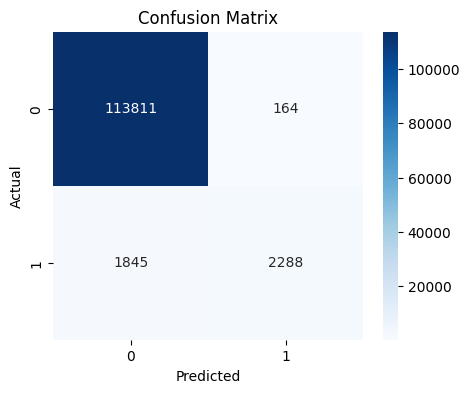

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

# Memulai experiment tracking dengan MLflow
mlflow.set_experiment("Fraud_Detection_Experiment")

with mlflow.start_run(run_name="Best_CatBoost_Model"):
    # Mengambil parameter terbaik dari hasil Optuna
    best_params = study.best_params

    # Meningkatkan jumlah iterasi untuk performa final
    best_params['iterations'] = 500

    # Inisialisasi dan melatih model final
    model = CatBoostClassifier(**best_params, eval_metric='AUC', logging_level='Silent')
    model.fit(X_train, y_train)

    # Memprediksi probabilitas dan label
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Menghitung AUC Score
    final_auc = roc_auc_score(y_test, y_pred_proba)

    # Mencatat (logging) parameter dan metrik ke MLflow
    mlflow.log_params(best_params)
    mlflow.log_metric("auc", final_auc)

    # Menampilkan hasil evaluasi
    print(f"Final AUC on Test Set: {final_auc}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Visualisasi Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()